### **Lunar Lander REINFORCE (TORCH)**

This notebook implements the simple REINFORCE algorithm:

1. Generate one full episode with the current policy.
2. Compute the discounted return `G_t` from each time step.
3. Update the policy with `G_t * grad(log pi(a_t | s_t))`.

There is only a policy network: no critic, no value network, and no PPO clipping.

In [3]:
import os
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import gymnasium as gym

import sys
sys.stderr = open('err.txt', 'w')

In [2]:
# --- Hyperparameters ---
gamma = 0.99
learning_rate = 1e-3
solved_threshold = 200
MAX_EPISODES = 3000
EVAL_EPS = 10

# Optional but useful for numerical stability in practice.
normalize_returns = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [3]:
# Check GPU status
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
    x = torch.randn(1000, 1000, device="cuda")
    y = x @ x
    print("Matmul on GPU OK, result shape:", y.shape)
else:
    print("Running on CPU.")

PyTorch version: 2.9.0+cu128
CUDA available: False
Running on CPU.


In [4]:
env = gym.make("LunarLander-v3")
obs_dim = env.observation_space.shape[0]
n_actions = env.action_space.n
print(f"obs_dim={obs_dim}, n_actions={n_actions}")

obs_dim=8, n_actions=4


In [5]:
# --- Policy network ---
class PolicyNetwork(nn.Module):
    def __init__(self, obs_dim, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, n_actions),
        )

    def forward(self, x):
        return self.net(x)        # raw logits, not probabilities


policy = PolicyNetwork(obs_dim, n_actions).to(device)
optimizer = optim.Adam(policy.parameters(), lr=learning_rate)


In [6]:
# --- Return computation ---
def compute_returns(rewards, gamma=0.99):
    """Compute G_t for every step of one full episode."""
    returns = []
    G = 0.0
    for reward in reversed(rewards):
        G = reward + gamma * G
        returns.insert(0, G)
    return np.array(returns, dtype=np.float32)


In [7]:
# --- Generate one full episode using the policy ---
def generate_episode(env, policy):
    log_probs = []
    rewards = []
    obs, _ = env.reset()
    done = False

    while not done:
        obs_tensor = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        logits = policy(obs_tensor)
        dist = torch.distributions.Categorical(logits=logits)
        action = dist.sample()

        next_obs, reward, terminated, truncated, _ = env.step(action.item())

        log_probs.append(dist.log_prob(action).squeeze())
        rewards.append(reward)

        obs = next_obs
        done = terminated or truncated

    return log_probs, rewards


In [8]:
# --- REINFORCE update step ---
def reinforce_update(log_probs, rewards):
    returns = compute_returns(rewards, gamma)

    if normalize_returns:
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

    returns_tensor = torch.as_tensor(returns, dtype=torch.float32, device=device)
    log_probs_tensor = torch.stack(log_probs)

    # Gradient descent on the negative objective is equivalent to:
    # theta <- theta + alpha * G_t * grad(log pi(a_t | s_t))
    loss = -(log_probs_tensor * returns_tensor).sum()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return float(loss.item())


In [9]:
# --- Evaluation ---
def evaluate_policy(env, policy, n_episodes=10, deterministic=False):
    total_rewards = []
    for episode in range(n_episodes):
        obs, _ = env.reset(seed=10_000 + episode)
        done = False
        ep_reward = 0.0

        while not done:
            obs_tensor = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            with torch.no_grad():
                logits = policy(obs_tensor)
                if deterministic:
                    action = torch.argmax(logits, dim=-1).item()
                else:
                    dist = torch.distributions.Categorical(logits=logits)
                    action = dist.sample().item()

            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            ep_reward += reward

        total_rewards.append(ep_reward)

    return float(np.mean(total_rewards)), float(np.std(total_rewards))


In [10]:
# --- Training loop ---
episode_rewards = []
eval_rewards = []
start_time = time.time()

for episode in range(MAX_EPISODES):
    # 1. Generate one full episode.
    log_probs, rewards = generate_episode(env, policy)

    # 2. Compute returns and update the policy.
    reinforce_update(log_probs, rewards)

    total_reward = sum(rewards)
    episode_rewards.append(total_reward)

    # 3. Evaluate periodically.
    if (episode + 1) % 10 == 0:
        mean_r, std_r = evaluate_policy(env, policy, n_episodes=EVAL_EPS, deterministic=False)
        eval_rewards.append(mean_r)
        elapsed = (time.time() - start_time) / 60.0
        print(f"Episode {episode+1:4d}/{MAX_EPISODES}  "
              f"train reward: {total_reward:+8.2f}  "
              f"eval reward ({EVAL_EPS} eps): {mean_r:7.2f} ± {std_r:5.1f}  "
              f"elapsed: {elapsed:.1f} min")

        if mean_r >= solved_threshold:
            print(f"\nEnvironment solved in {episode+1} episodes!")
            break

print(f"\nTraining done in {(time.time()-start_time)/60:.2f} minutes.")


Episode   10/3000  train reward:  -282.27  eval reward (10 eps): -218.98 ± 110.3  elapsed: 0.0 min
Episode   20/3000  train reward:  -437.00  eval reward (10 eps): -161.79 ±  94.1  elapsed: 0.0 min
Episode   30/3000  train reward:   -95.03  eval reward (10 eps): -243.91 ± 156.9  elapsed: 0.0 min
Episode   40/3000  train reward:   -84.66  eval reward (10 eps): -221.57 ± 115.2  elapsed: 0.0 min
Episode   50/3000  train reward:   -89.47  eval reward (10 eps): -195.35 ±  86.9  elapsed: 0.0 min
Episode   60/3000  train reward:  -187.94  eval reward (10 eps): -121.91 ±  69.9  elapsed: 0.0 min
Episode   70/3000  train reward:  -135.85  eval reward (10 eps): -129.79 ±  30.0  elapsed: 0.1 min
Episode   80/3000  train reward:   -81.86  eval reward (10 eps): -117.95 ±  47.2  elapsed: 0.1 min
Episode   90/3000  train reward:  -100.71  eval reward (10 eps): -118.60 ±  76.1  elapsed: 0.1 min
Episode  100/3000  train reward:   +60.60  eval reward (10 eps): -119.57 ±  50.0  elapsed: 0.1 min
Episode  1

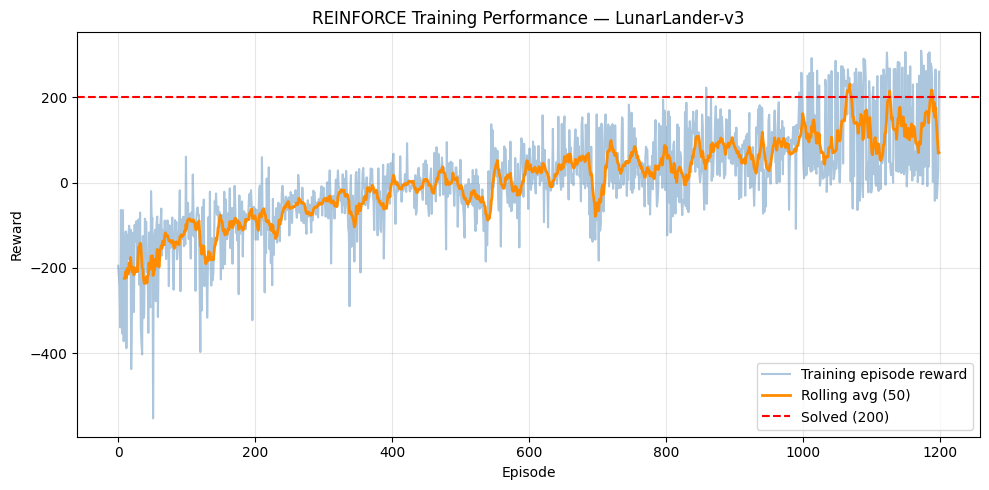

In [16]:
# Plot rewards
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, label='Training episode reward', alpha=0.45, color='steelblue')

if len(episode_rewards) >= 10:
    rolling = np.convolve(episode_rewards, np.ones(10)/10, mode='valid')
    plt.plot(range(9, len(episode_rewards)), rolling,
             label='Rolling avg (10)', color='darkorange', linewidth=2)

plt.axhline(y=solved_threshold, color='red', linestyle='--', label=f'Solved ({solved_threshold})')
plt.title('REINFORCE Training Performance — LunarLander-v3')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [12]:
# Test for 10 episodes using the trained policy (deterministic)
start_time = time.time()
test_rewards = []

for e_test in range(10):
    state, _ = env.reset()
    total_reward = 0.0
    steps = 0

    while True:
        state_tensor = torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            logits = policy(state_tensor)
        action = torch.argmax(logits, dim=-1).item()

        next_state, reward, terminated, truncated, _ = env.step(action)
        state = next_state
        steps += 1
        total_reward += reward

        if terminated or truncated:
            print(f"Test Episode {e_test+1:2d}/10  Reward: {total_reward:+8.2f}  "
                  f"Steps: {steps:4d}  Terminated: {terminated}")
            test_rewards.append(total_reward)
            break

print(f"\nMean test reward: {np.mean(test_rewards):.2f}")
print(f"Testing completed in {(time.time()-start_time)/60:.2f} minutes")


Test Episode  1/10  Reward:  +232.61  Steps:  430  Terminated: True
Test Episode  2/10  Reward:  +195.51  Steps:  417  Terminated: True
Test Episode  3/10  Reward:  +184.12  Steps:  407  Terminated: True
Test Episode  4/10  Reward:   +16.77  Steps:  364  Terminated: True
Test Episode  5/10  Reward:   -66.07  Steps:  318  Terminated: True
Test Episode  6/10  Reward:   -58.55  Steps:  414  Terminated: True
Test Episode  7/10  Reward:  +227.06  Steps:  452  Terminated: True
Test Episode  8/10  Reward:  +232.87  Steps:  525  Terminated: True
Test Episode  9/10  Reward:   -38.88  Steps:  351  Terminated: True
Test Episode 10/10  Reward:  +239.25  Steps:  470  Terminated: True

Mean test reward: 116.47
Testing completed in 0.00 minutes


#### **Render one episode as a GIF**

In [13]:
# Render a single test episode and save as GIF.
from PIL import Image

render_env = gym.make("LunarLander-v3", render_mode='rgb_array')
frames = []

state, _ = render_env.reset()
total_reward = 0.0

while True:
    state_tensor = torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        logits = policy(state_tensor)
    action = torch.argmax(logits, dim=-1).item()
    
    next_state, reward, terminated, truncated, _ = render_env.step(action)
    frames.append(render_env.render())
    total_reward += reward
    state = next_state
    
    if terminated or truncated:
        print(f"Rendered episode reward: {total_reward:.2f}")
        break

render_env.close()

def save_frames_as_gif(frames, path='./', filename='LunarLander_REINFORCE.gif'):
    images = [Image.fromarray(frame) for frame in frames]
    gif_path = os.path.join(path, filename)
    images[0].save(gif_path, save_all=True, append_images=images[1:],
                   duration=50, loop=0)
    print(f"Saved GIF to: {gif_path}")

save_frames_as_gif(frames, filename='LunarLander_REINFORCE.gif')


Rendered episode reward: 247.65
Saved GIF to: ./LunarLander_REINFORCE.gif
